In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image_dataset_from_directory
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("huyphmnguyenthanh/vietnamese-money")
data_dir = os.path.join(path, "data")

Using Colab cache for faster access to the 'vietnamese-money' dataset.
Bên trong thư mục 'data' gồm có: ['100000', '20000', '00000', '50000', '10000', '500000', '200000', '2000', '1000']


In [ ]:
import kagglehub
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image_dataset_from_directory
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("huyphmnguyenthanh/vietnamese-money")
data_dir = os.path.join(path, "data")

folder_to_exclude = "00000"
clean_classes = [
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d)) and d != folder_to_exclude
]
clean_classes.sort()

print("Hệ thống sẽ chỉ train các lớp này:", clean_classes)

train_ds = image_dataset_from_directory(
    data_dir,
    class_names=clean_classes,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)
val_ds = image_dataset_from_directory(
    data_dir,
    class_names=clean_classes,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

class_names = train_ds.class_names
num_classes = len(class_names)

Using Colab cache for faster access to the 'vietnamese-money' dataset.
Hệ thống sẽ chỉ train các lớp này: ['1000', '10000', '100000', '2000', '20000', '200000', '50000', '500000']
Found 7955 files belonging to 8 classes.
Using 6364 files for training.
Found 7955 files belonging to 8 classes.
Using 1591 files for validation.


In [ ]:
def get_images_and_labels(dataset):
    all_images = []
    all_labels = []

    for images, labels in dataset:
        all_images.append(images.numpy())
        all_labels.append(labels.numpy())

    return np.concatenate(all_images), np.concatenate(all_labels)

x_train_raw, y_train_raw = get_images_and_labels(train_ds)
x_test_raw, y_test_raw = get_images_and_labels(val_ds)

x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

y_train = to_categorical(y_train_raw, num_classes=num_classes)
y_test = to_categorical(y_test_raw, num_classes=num_classes)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(6364, 128, 128, 3)
(6364, 8)
(1591, 128, 128, 3)
(1591, 8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.7827 - loss: 0.5940 - val_accuracy: 0.9862 - val_loss: 0.0464
Epoch 2/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9701 - loss: 0.0849 - val_accuracy: 0.9956 - val_loss: 0.0150
Epoch 3/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9802 - loss: 0.0591 - val_accuracy: 0.9987 - val_loss: 0.0031
Epoch 4/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9876 - loss: 0.0350 - val_accuracy: 0.9987 - val_loss: 0.0040
Epoch 5/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9866 - loss: 0.0416 - val_accuracy: 0.9975 - val_loss: 0.0063
Epoch 6/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9885 - loss: 0.0318 - val_accuracy: 0.9994 - val_loss: 0.0021
Epoch 7/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9943 - loss: 0.0171 - val_accuracy: 0.9987 - val_loss: 0.0087
Epoch 8/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9956 - loss: 0.0123 - val_acc

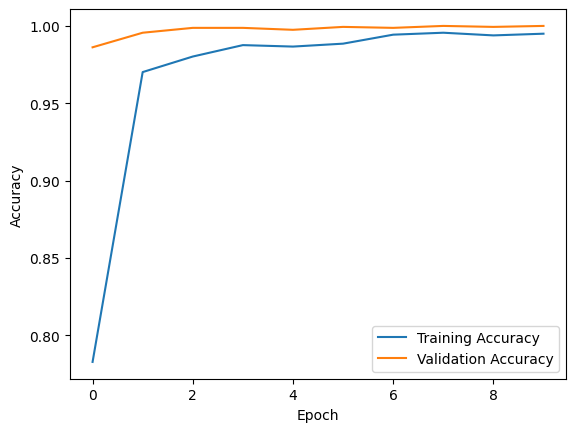

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
import matplotlib.pyplot as plt

img_width, img_height = 128, 128
batch_size = 32

model = Sequential([
    Conv2D(32,(3,3), activation = "relu", input_shape = (img_width, img_height, 3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation = "relu"),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3), activation = "relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation ='relu'),
    Dropout(0.5),
    Dense(num_classes,activation="softmax")])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs = 10, validation_data=(x_test, y_test), batch_size=batch_size)

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
model.save("money.h5")

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('money.h5')

# Print a summary of the loaded model to verify
loaded_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,674 (12.61 MB)

 Trainable params: 3,305,672 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

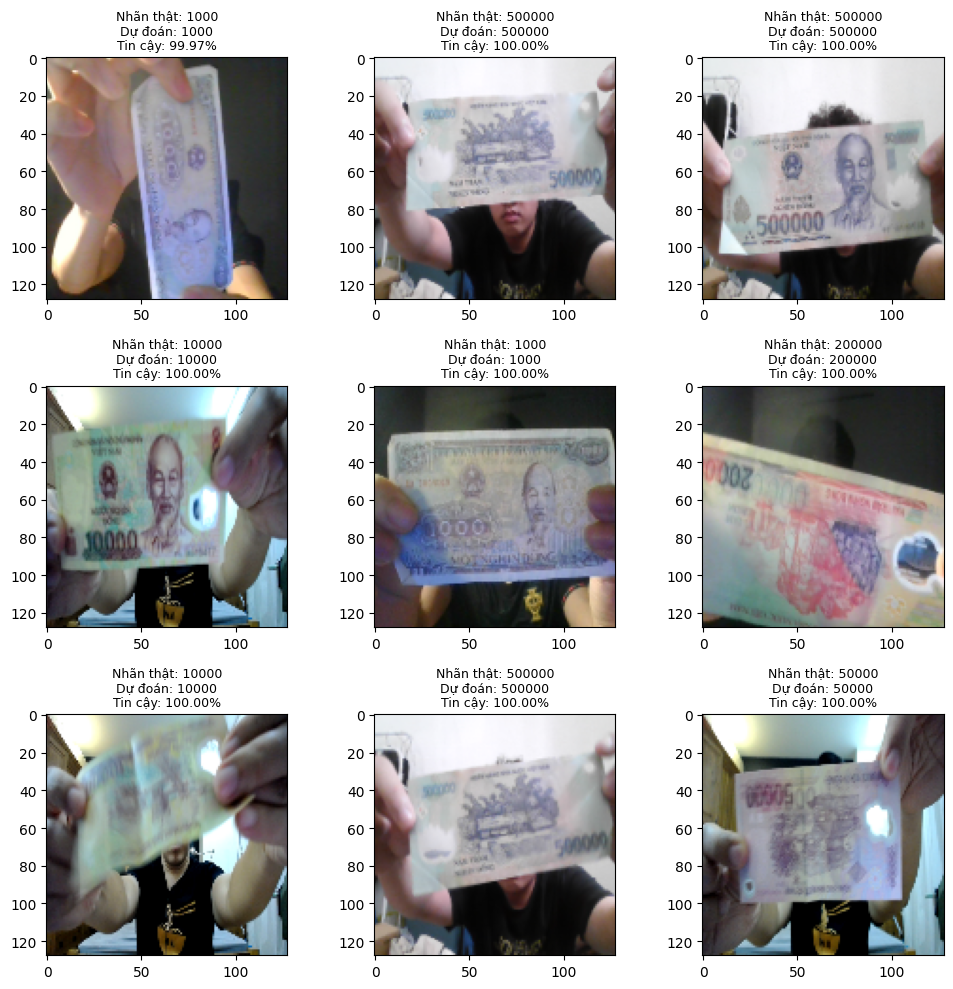

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

indices = np.random.choice(len(x_test), 9, replace=False)

plt.figure(figsize=(10, 10))

for i, index in enumerate(indices):
    img = x_test[index]

    true_label_index = np.argmax(y_test[index])
    true_label = class_names[true_label_index]

    prediction = loaded_model.predict(
        img.reshape(1, img_height, img_width, 3),
        verbose=0
    )

    predicted_label_index = np.argmax(prediction)
    predicted_label = class_names[predicted_label_index]
    confidence = np.max(prediction) * 100

    plt.subplot(3, 3, i + 1)

    # Chặn giá trị ảnh về đúng khoảng 0 đến 1 để không bị Warning
    plt.imshow(np.clip(img, 0, 1))

    plt.title(
        f"Nhãn thật: {true_label}\nDự đoán: {predicted_label}\nTin cậy: {confidence:.2f}%",
        fontsize=9
    )

plt.tight_layout()
plt.show()
